### Importação das bibliotecas e carregamento do dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('E Commerce Dataset.csv')

# Análise exploratória dos dados

Visualização de uma amostra inicial do dataset

In [3]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


Visualização de informações sobre o dataset

In [ ]:
# o número de linhas e colunas do dataset
print(df.shape, '\n')

# tipos de colunas e quantidade de valores não nulos
print(df.info(), '\n')

# sumário estatístico descritivo do dataset
print(df.describe(), '\n')

# quantidade de valores nulos em cada coluna
print(df.isna().sum(), '\n')

# quantos valores de cada tem na coluna target
print(df['Churn'].value_counts())

(5630, 20) 

<class 'pandas.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   str    
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   str    
 7   Gender                       5630 non-null   str    
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   str    
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   str    
 13  NumberOfAddress 

In [5]:
df['Churn'].head()

0    1
1    1
2    1
3    1
4    1
Name: Churn, dtype: int64

Verifiquei os valores de algumas features que fiquei em dúvida na interpretação para ver quais eram categoricas (0,1) e quais eram numéricas para me ajudar a intepretalas corretamente

In [ ]:
print(df['SatisfactionScore'].unique())
print(df['Complain'].unique())
print(df['HourSpendOnApp'].unique())
print(df['CouponUsed'].unique())

[2 3 5 4 1]
[1 0]
[ 3.  2. nan  1.  0.  4.  5.]
[ 1.  0.  4.  2.  9.  6. 11. nan  7. 12. 10.  5.  3. 13. 15.  8. 14. 16.]


# Visualização gráfica dos dados

Verifiquei o balanceamento do target utilizando um gráfico de contagem

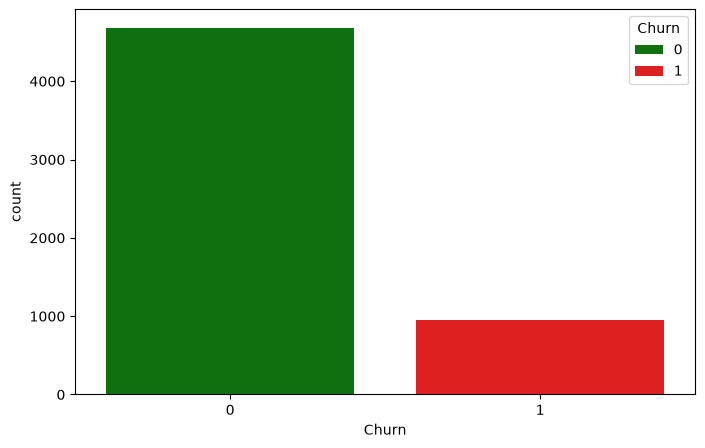

In [6]:
plt.figure(figsize=(8,5))
sns.countplot(df, x='Churn', hue='Churn', palette=['green', 'red'])
plt.show()

Verifiquei a média de cupons utilizados por cada grupo

Objetivo: Validar se o uso de cupons de desconto realmente ajuda a impedir do cliente cancelar o serviço

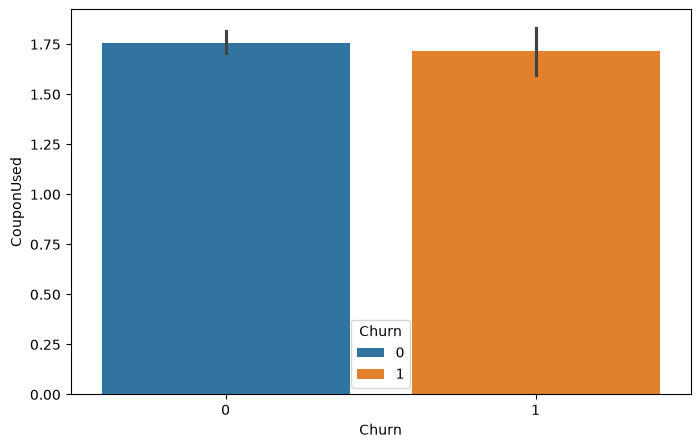

In [61]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Churn', y='CouponUsed', hue='Churn')
plt.show()

Verifiquei a distribuição das nivel de satisfação dos clientes

Objetivo: obter algum insight

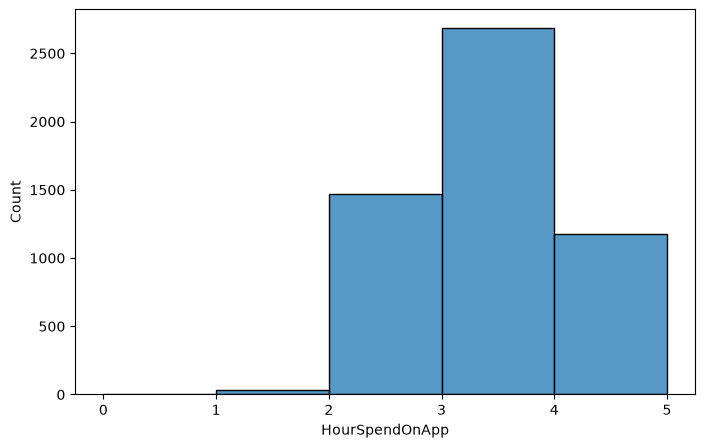

In [31]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='HourSpendOnApp', bins=5)
plt.show()

Verifiquei a distribuição da distancia do armazém até a casa dos clientes

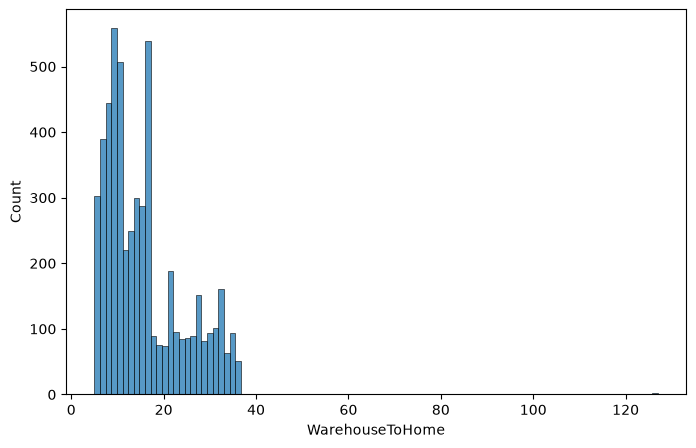

In [39]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='WarehouseToHome', bins=100)
plt.show()

No gráfico acima notei que havia um valor extremamente distante dos outros, então decidi plotar um gráfico de caixa para verificar se era um outlier

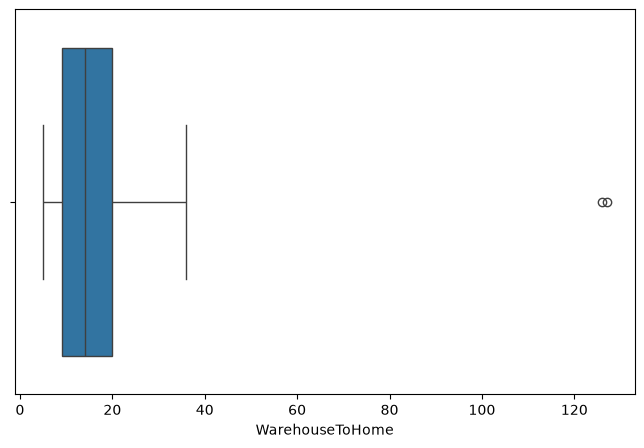

In [37]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='WarehouseToHome')
plt.show()

taxa de reclamações entre os grupos que cancelaram e não cancelaram o serviço

Objetivo: verificar se reclamações é um fator relevante para o cliente deixar de assinar o serviço

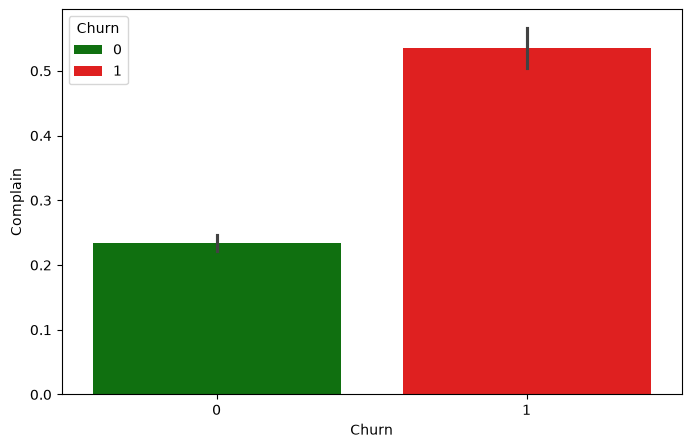

In [53]:
plt.figure(figsize=(8,5))
sns.barplot(df, x='Churn', y='Complain', hue='Churn', palette=['green', 'red'])
plt.show()

nivel de satisfação entre os grupos

Objetivo: Verificar se o nível de satisfação é um fator relevante para o cancelamento do serviço

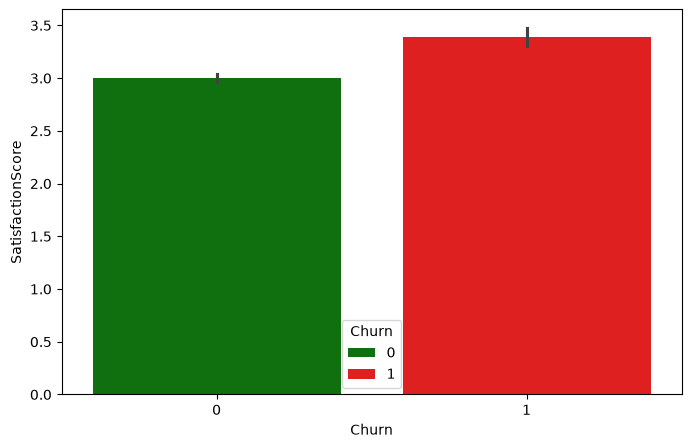

In [15]:
plt.figure(figsize=(8,5))
sns.barplot(df, x='Churn', y='SatisfactionScore', hue='Churn', palette=['Green', 'Red'])
plt.show()

a distancia média entre o armazém e o cliente dos grupos que reclamaram e dos grupos que cancelaram o serviço

o objetivo desse gráfico foi testar minha hipótese de que os clientes que moram mais longe do armazem acabam tendo mais reclamações e por conta disso acabam deixando o serviço

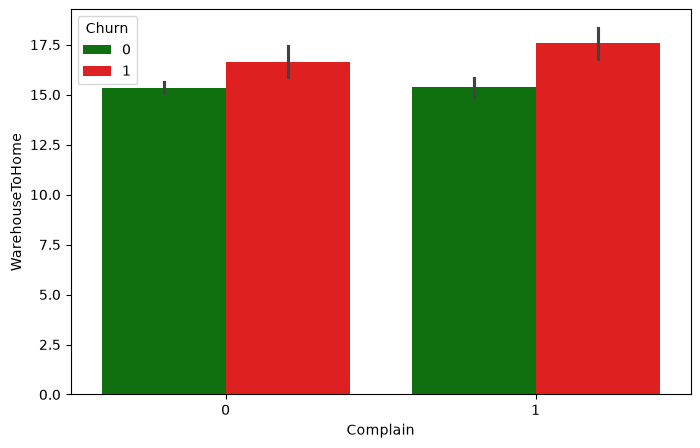

In [59]:
plt.figure(figsize=(8,5))
sns.barplot(df, x='Complain', y='WarehouseToHome', hue='Churn', palette=['Green', 'Red'])
plt.show()

Verifiquei a quantidade média de pedidos entre os clientes que cancelaram ou não o serviço

Objetivo: testar minha hipótese de que os clientes que cancelaram o serviço foram os que mais compraram dentro da plataforma antes de cancelar o serviço

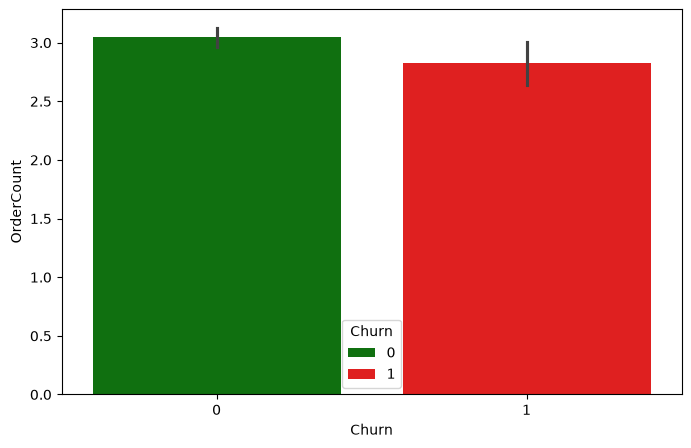

In [62]:
plt.figure(figsize=(8,5))
sns.barplot(df, x='Churn', y='OrderCount', hue='Churn', palette=['Green', 'Red'])
plt.show()

Verificar a correlação entre Distancia do cliente, quantidade de pedidos e o cancelamento do serviço

Objetivo: testar a hipótese de que existe a distância do cliente afeta a quantidade de pedidos que ele faz e consequentemente afeta a decisão dele de cancelar o serviço

[]

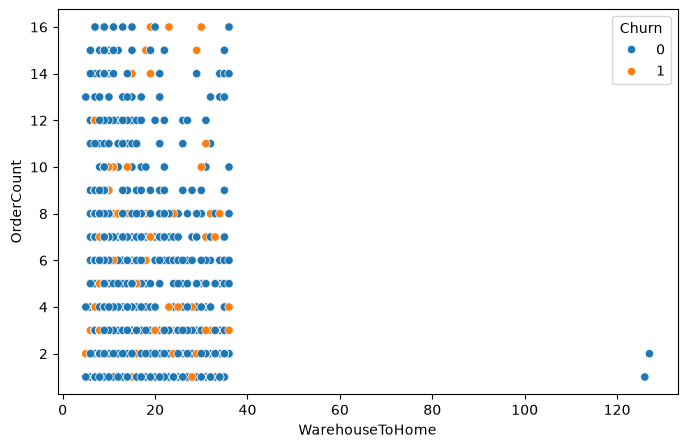

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='WarehouseToHome', y='OrderCount', hue='Churn')
plt.title('Correlação entre ')
plt.plot()

Fiz uma matriz de correlação das variaveis numéricas para verificar e validar as correlações reais das variaveis

Objetivo: Validar as correlações e não correlações que identifiquei nos gráficos anteriores e ver outras correlações que eu posso não ter percebido

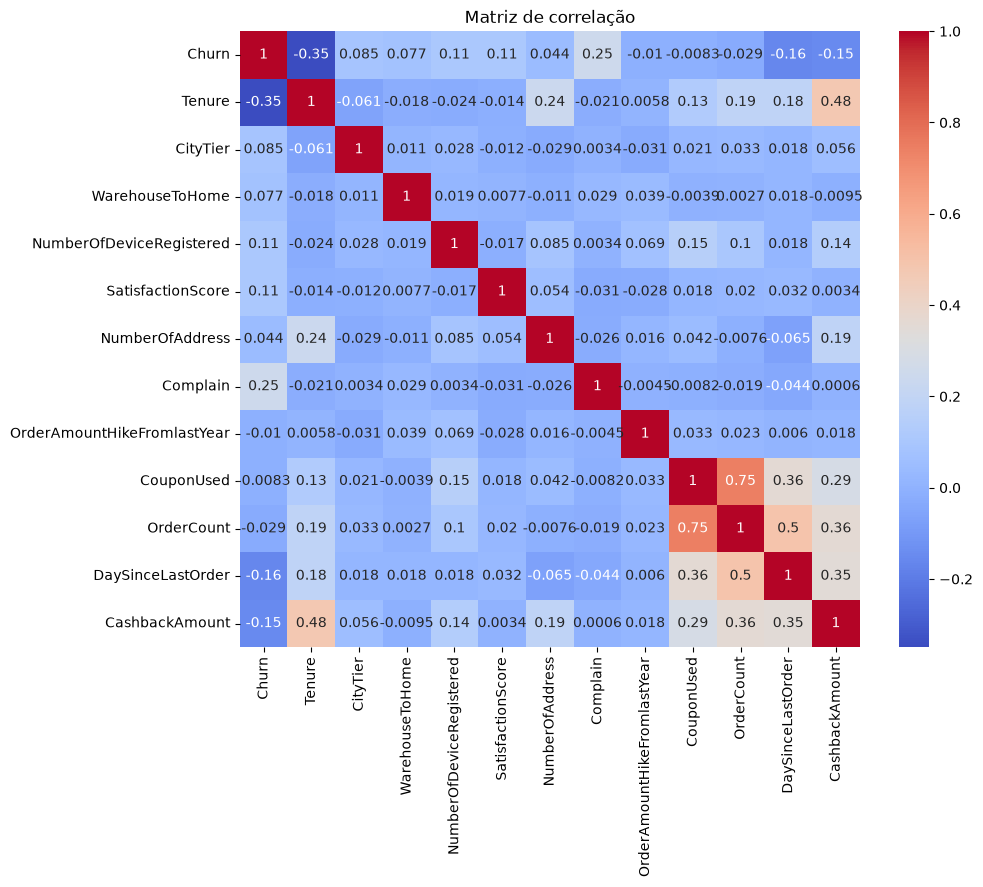

In [77]:
df_numeric = df[['Churn', 'Tenure', 'CityTier', 'WarehouseToHome',
                'NumberOfDeviceRegistered', 'SatisfactionScore',
                'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear',
                'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']]

df_corr = df_numeric.corr()

plt.figure(figsize=(10,8))
sns.heatmap(data=df_corr, annot=True, cmap='coolwarm')
plt.title('Matriz de correlação')
plt.show()

### Insights

A base esta extremamente desbalanceada quanto ao target, a maior parte dos dados são de clientes que não cancelaram o serviço e isso é um problema pois o que precisamos prever são os clientes que vão cancelar o serviço, então vou precisar aplicar técnicas de balanceamento para o modelo ter 50/50 dos 2 casos.
Os cupons não são um fator relevante para retenção dos clientes, isso é importante pois talvez distribuir cupons de descontos não seja a melhor estratégia para reter clientes no serviço.
O maior fator que faz os clientes cancelarem o serviço são as reclamações, clientes que reclamam tem uma tendência muito maior, praticamente o dobro de chance de cancelarem o serviço do que os clientes que não tiveram nenhuma reclamação
e o maior fator para retenção do cliente é o tempo de permanência no serviço (Tenure) na empresa, e este fator é influenciado pela quantidade de cashback que também ifluência o churn como mostrado na matriz de correlação. Talvez utilizar o cashback seja uma estratégia melhor de retenção ao cliente do que cupons de desconto.

# Preparação dos dados (Data Prep)

In [91]:
df_duplicate = df.drop(columns=['CustomerID'])
df_duplicate.drop_duplicates()

,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5623,0,5.0,Computer,1,12.0,Credit Card,Male,4.0,4,Laptop & Accessory,5,Single,2,0,20.0,2.0,2.0,NaN,224
5624,0,1.0,Mobile Phone,3,12.0,UPI,Female,2.0,5,Mobile Phone,3,Single,2,0,19.0,2.0,2.0,1.0,155
5626,0,13.0,Mobile Phone,1,13.0,Credit Card,Male,3.0,5,Fashion,5,Married,6,0,16.0,1.0,2.0,NaN,225
5627,0,1.0,Mobile Phone,1,11.0,Debit Card,Male,3.0,2,Laptop & Accessory,4,Married,3,1,21.0,1.0,2.0,4.0,186
